In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Nettoyage des données

In [19]:
# Charger le fichier Excel
df = pd.read_excel('Sujet6.xlsx')

# 1) Nettoyage colonnes de données textuelles
text_col = ['gender', 'subscription', 'region', 'device_type']
text_col = [c for c in text_col if c in df.columns]

for col in text_col:
    # Normaliser en chaîne de char
    df[col] = df[col].astype(str)
    # Supprimer # et ? puis garder uniquement lettres et espaces
    df[col] = df[col].str.replace('[#?]', '', regex=True)
    df[col] = df[col].str.replace('[^A-Za-zÀ-ÖØ-öø-ÿ\\s]', '', regex=True)
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace('\\s+', ' ', regex=True)
    # Convertir en majuscule et enlever accents
    df[col] = df[col].str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('ascii')
    df[col] = df[col].str.upper()

# Supprimer lignes textuelles vides ou manquantes
if text_col:
    df = df.dropna(subset=text_col)
    for col in text_col:
        df = df[df[col].str.len() > 0]

# 2) Nettoyage colonne de données numériques
decimal_columns = ['time_on_plateforme', 'avg_session_duration', 'geo_lat', 'geo_lon', 'engagement_score', 'churn_risk']
numeric_columns = [c for c in df.columns if c not in text_col]

for col in numeric_columns:
    # Nettoyage initial des valeurs textuelles
    df[col] = df[col].astype(str).fillna('')
    df[col] = df[col].str.replace('[#?]', '', regex=True)
    # Extrait le premier nombre dans la chaîne (ex: '522abc' -> 522)
    df[col] = df[col].str.extract('(-?[0-9]+(?:\\.[0-9]+)?)', expand=False)
    # Conversion numérique
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Pas de nb négatifs
    df[col] = df[col].abs()
    # Découper en int sauf colonnes décimales autorisées
    if col not in decimal_columns:
        df[col] = df[col].apply(lambda x: int(x) if pd.notna(x) else x)

# Supprimer les lignes avec valeurs non numériques
if numeric_columns:
    df = df.dropna(subset=numeric_columns)

# 3) Nettoyage global
# Supprimer lignes complètement vides
df = df.dropna(how='all')
# Supprimer lignes avec >50% de valeurs manquantes
df = df.dropna(thresh=int(len(df.columns)*0.5))
# Supprimer doublons
df = df.drop_duplicates()

# Sauvegarder le fichier nettoyé
df.to_csv('data_v3.csv', index=False)
print("\n✓ Données nettoyées")



✓ Données nettoyées


Visualisation n°1 : Temps moyen et durée de session moyenne par tranche d'âge

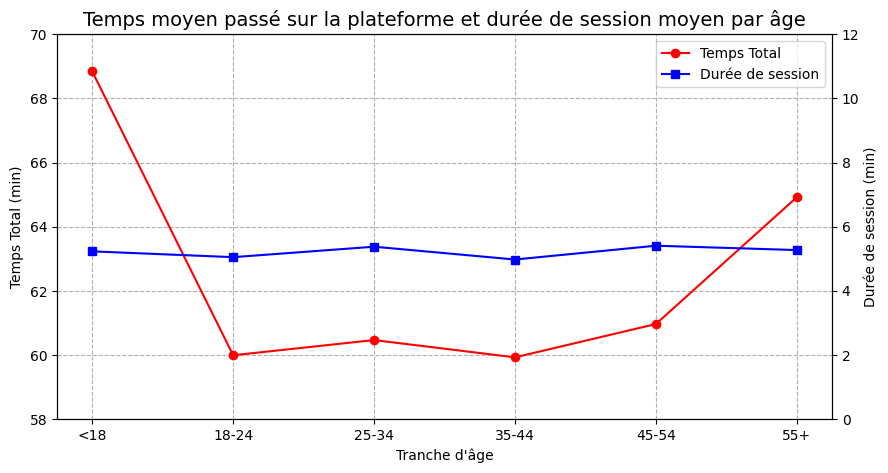

In [47]:
# 1. Données (simplifié)
df = pd.read_csv('data_v3.csv')
df['tranche'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 55, 100], labels=['<18','18-24','25-34','35-44','45-54','55+'])
stats = df.groupby('tranche').mean(numeric_only=True)

# 2. Taille du graphique
plt.figure(figsize=(10, 5))

# Courbe 1 (Axe gauche)
ligne1, = plt.plot(stats.index, stats['time_on_platform'], 'r-o', label='Temps Total')
plt.xlabel('Tranche d\'âge')
plt.ylabel('Temps Total (min)')
plt.grid(True, linestyle='--')
plt.ylim(58, 70)

# Création de l'axe de droite
ax2 = plt.twinx() 
ligne2, = ax2.plot(stats.index, stats['avg_session_duration'], 'b-s', label='Durée de session')
ax2.set_ylabel('Durée de session (min)')
ax2.set_ylim(0, 12)

#Légende
lns = [ligne1, ligne2]
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='upper right')

plt.title('Temps moyen passé sur la plateforme et durée de session moyen par âge', fontsize=14)
plt.show()

Visualisation n°2 : Comparaison des différentes actions effectuées par genre

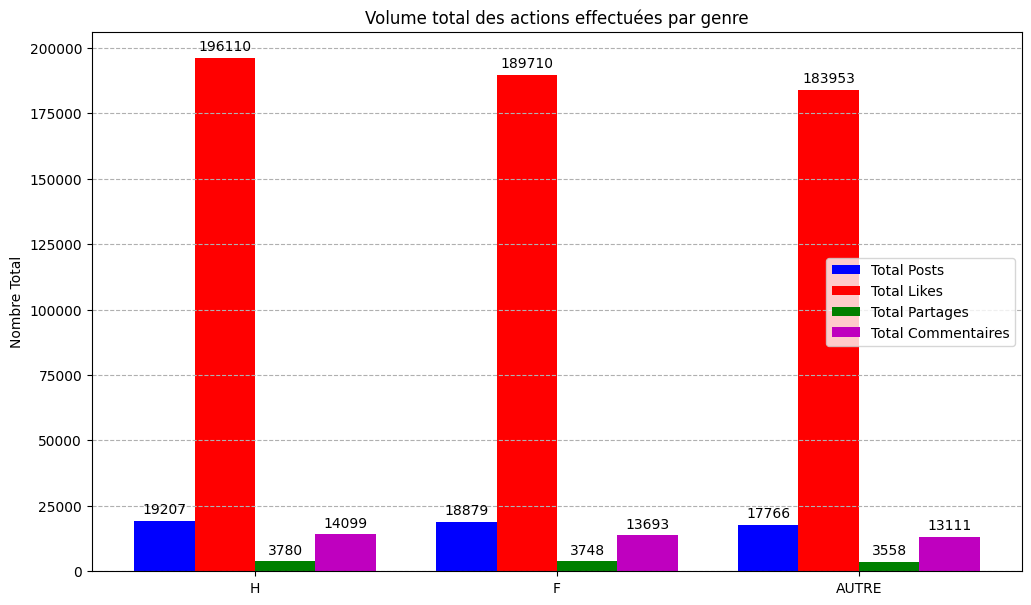

In [ ]:
# 1. Préparation des données
df = pd.read_csv('data_v3.csv')
df['total_posts'] = df['photos_posted'] + df['videos_posted']

# Calcul des totaux par genre
stats = df.groupby('gender')[['total_posts', 'likes', 'shares', 'comments_written']].sum().reindex(['H', 'F', 'AUTRE'])

# 2. Création du graphique
plt.figure(figsize=(12, 7))

# On définit les indices
indices = range(len(stats.index))
larg = 0.2  # Largeur des barres

# Calcul des positions des batons
pos1 = [x - 1.5*larg for x in indices]
pos2 = [x - 0.5*larg for x in indices]
pos3 = [x + 0.5*larg for x in indices]
pos4 = [x + 1.5*larg for x in indices]

# Tracé des batons
b1 = plt.bar(pos1, stats['total_posts'], larg, label='Total Posts', color='b')
b2 = plt.bar(pos2, stats['likes'], larg, label='Total Likes', color='r')
b3 = plt.bar(pos3, stats['shares'], larg, label='Total Partages', color='g')
b4 = plt.bar(pos4, stats['comments_written'], larg, label='Total Commentaires', color='m')

# Ajout des valeurs sur les bâtons
plt.bar_label(b1, padding=3)
plt.bar_label(b2, padding=3)
plt.bar_label(b3, padding=3)
plt.bar_label(b4, padding=3)

# Configuration
plt.xticks(indices, stats.index)
plt.ylabel('Nombre Total')
plt.title('Volume total des actions effectuées par genre')
plt.legend()
plt.grid(axis='y', linestyle='--')

plt.show()

Visualisation n°3 : Comparaison entre le temps passé et à quel point l'utilisateur est actif

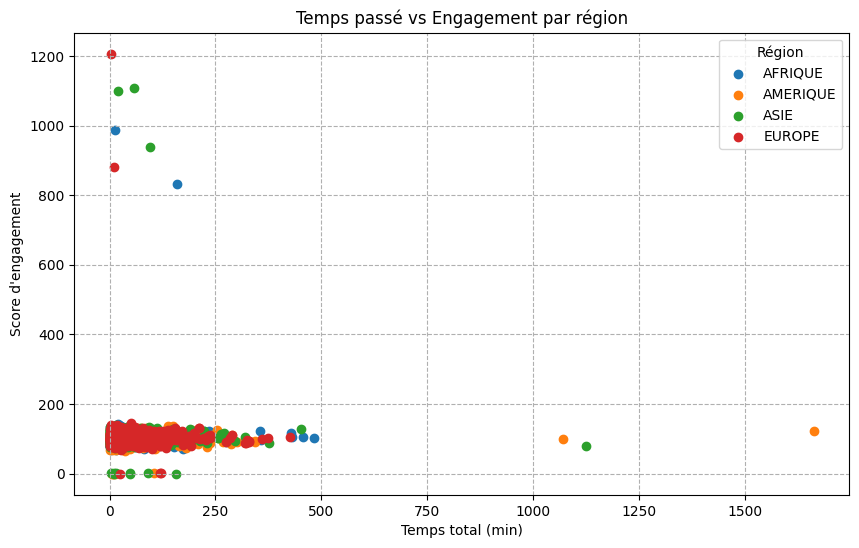

In [13]:
# 1. Données
df = pd.read_csv('data_v3.csv')

# Filtrage sans undefined
df = df[df['region'] != 'UNDEFINED']

# 2. Graphique
fig, graph = plt.subplots(figsize=(10, 6))

# Regroupement par région et nuage de points
for name, group in df.groupby('region'):
    graph.scatter(group['time_on_platform'], group['engagement_score'], label=name)

# 3. Les caractéristiques 
plt.title('Temps passé vs Engagement par région')
plt.xlabel('Temps total (min)')
plt.ylabel('Score d\'engagement')
plt.legend(title='Région')
plt.grid(True, linestyle='--')

plt.show()